## LSTM CODE

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Load and preprocess data
data = pd.read_csv('C:\\Users\\srika\\Downloads\\review_data(Sheet1).csv')  # Replace with your dataset path

# Ensure 'reviewText' column is of type string
data['reviewText'] = data['reviewText'].astype(str)

# Define preprocessing function
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(token) for token in tokens if token.isalpha() and token not in stop_words]
    return ' '.join(tokens)

# Apply preprocessing
data['reviewText'] = data['reviewText'].apply(preprocess_text)

# Initialize tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(data['reviewText'])
sequences = tokenizer.texts_to_sequences(data['reviewText'])

# Pad sequences
max_length = 100  # Adjust based on your data
padded_sequences = pad_sequences(sequences, maxlen=max_length)

# Prepare labels
num_classes = len(data['overall'].unique())
labels = pd.get_dummies(data['overall']).values

# Split data into training and testing sets
train_data = data.sample(frac=0.9, random_state=42)
test_data = data.drop(train_data.index)

train_sequences = tokenizer.texts_to_sequences(train_data['reviewText'])
padded_train = pad_sequences(train_sequences, maxlen=max_length)
train_labels = pd.get_dummies(train_data['overall']).values

test_sequences = tokenizer.texts_to_sequences(test_data['reviewText'])
padded_test = pad_sequences(test_sequences, maxlen=max_length)
test_labels = pd.get_dummies(test_data['overall']).values

# Create LSTM model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=100, input_length=max_length))
model.add(Conv1D(64, kernel_size=3, activation='relu'))
model.add(Bidirectional(LSTM(100, dropout=0.2)))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax', kernel_regularizer='l2', bias_regularizer='l2'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train model
model.fit(padded_train, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate model
loss, accuracy = model.evaluate(padded_test, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

# Define predefined responses for each label
responses = {
    0: "Thank you for your feedback. We will work on improving this aspect.",
    1: "We appreciate your comments. We'll consider your suggestions.",
    2: "Thank you for your positive review! We're glad you had a good experience.",
    3: "We apologize for the inconvenience. Please contact support for assistance.",
    4: "Thank you for your detailed feedback. We will take your points into consideration."
}

# Define response generation function
def generate_response(text):
    processed_text = preprocess_text(text)
    sequence = tokenizer.texts_to_sequences([processed_text])
    padded_sequence = pad_sequences(sequence, maxlen=max_length)
    prediction = model.predict(padded_sequence)
    label = np.argmax(prediction)
    return responses.get(label, "Sorry, I cannot provide a response for this input.")

# Example usage
user_review = "The product is amazing, I loved it!"
response = generate_response(user_review)
print(response)





Epoch 1/10


254/254 [==============================] - 51s 161ms/step - loss: 1.0867 - accuracy: 0.6286 - val_loss: 1.0050 - val_accuracy: 0.6356
Epoch 2/10
254/254 [==============================] - 38s 149ms/step - loss: 0.8745 - accuracy: 0.6678 - val_loss: 0.9413 - val_accuracy: 0.6511
Epoch 3/10
254/254 [==============================] - 37s 147ms/step - loss: 0.7510 - accuracy: 0.7102 - val_loss: 1.0128 - val_accuracy: 0.6444
Epoch 4/10
254/254 [==============================] - 38s 151ms/step - loss: 0.6373 - accuracy: 0.7532 - val_loss: 1.0953 - val_accuracy: 0.5922
Epoch 5/10
254/254 [==============================] - 38s 149ms/step - loss: 0.5392 - accuracy: 0.8002 - val_loss: 1.1588 - val_accuracy: 0.6267
Epoch 6/10
254/254 [==============================] - 38s 150ms/step - loss: 0.4597 - accuracy: 0.8337 - val_loss: 1.3204 - val_accuracy: 0.6178
Epoch 7/10
254/254 [==============================] - 38s 150ms/step - loss: 0.3997 - accuracy: 0.8591 - val_loss: 1.3791 - v

## FINAL RANDOM FOREST CODE

Accuracy: 0.8013333333333333
Precision: 0.7425724651739464
Recall: 0.8013333333333333


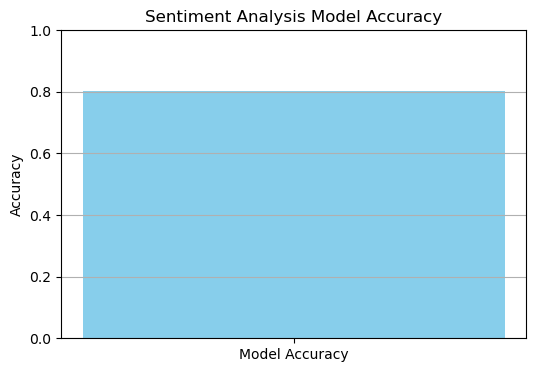

In [5]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.pipeline import make_pipeline
import re
import random
import tkinter as tk
import matplotlib.pyplot as plt

# Load data from CSV file
df = pd.read_csv("C:\\Users\\srika\\Downloads\\review_data(Sheet1).csv")

# Clean the column names
df.columns = df.columns.str.strip()

# Ensure the 'reviewText' and 'overall' columns exist
if 'reviewText' not in df.columns or 'overall' not in df.columns:
    raise KeyError("The required columns are missing in the dataset.")

# Handle missing values
df['reviewText'] = df['reviewText'].fillna('')

# Map 'overall' rating to sentiment labels
def map_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

df['sentiment'] = df['overall'].apply(map_sentiment)

# Define bags of words for neutral and negative sentiment
negative_words = [
    'waste', 'overpriced', 'less than expected', 'worst', 'bad', 'not all good', 'expensive',
    'not good', 'terrible', 'too expensive', 'disappointing', 'poor', 'horrible', 
    'unpleasant', 'awful', 'regret', 'pathetic', 'substandard', 'unworthy', 
    'flawed', 'unacceptable', 'unsatisfactory', 'inferior', 'dissatisfied', 
    'cheap quality', 'ineffective','hate'
]

neutral_words = [
    'okay', 'better', 'can try', 'average', 'decent', 'fine', 'satisfactory', 
    'not bad', 'acceptable', 'mediocre', 'so-so', 'nothing special', 'alright', 
    'reasonable', 'fair', 'ordinary', 'passable', 'all right', 'tolerable', 
    'modest', 'standard', 'not great', 'just okay', 'not the best'
]

# Text cleaning function
def clean_text(text):
    text = re.sub(r'\W', ' ', text)  # Remove non-word characters
    text = text.lower()
    return text

# Apply the text cleaning function
df['reviewText'] = df['reviewText'].apply(clean_text)

# Split data into features (X) and target (y)
X = df['reviewText']
y = df['sentiment']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipeline with TF-IDF vectorizer and Random Forest classifier, with class weights
pipeline = make_pipeline(
    TfidfVectorizer(max_df=0.9, min_df=2),  # Adjusted TF-IDF to focus on frequent words
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
)

# Train the model
pipeline.fit(X_train, y_train)

# Test the model
y_pred = pipeline.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')

# Print the accuracy, precision, and recall
print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

# Plotting accuracy graph
def plot_accuracy(accuracy):
    plt.figure(figsize=(6, 4))
    plt.bar(['Model Accuracy'], [accuracy], color='skyblue')
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title('Sentiment Analysis Model Accuracy')
    plt.grid(axis='y')
    plt.show()

# Function to get random sentiment responses
def get_sentiment_response(sentiment):
    if sentiment == "positive":
        return random.choice([
            "We're thrilled to hear you loved it! Thank you for your positive feedback!",
            "Thank you for your kind words! We're happy you had a great experience!",
            "Your satisfaction means the world to us! Thanks for sharing your thoughts."
        ])
    elif sentiment == "negative":
        return random.choice([
            "We're sorry to hear that! Please let us know how we can improve your experience.",
            "We apologize for the inconvenience. Your feedback is important, and we'll address it promptly.",
            "Thank you for your feedback. We take your concerns seriously and will strive to improve."
        ])
    elif sentiment == "neutral":
        return random.choice([
            "Thank you for your feedback. We appreciate your thoughts.",
            "We understand it was an average experience. Your feedback is valuable to us!",
            "Thanks for the honest feedback. We hope to make your next experience better."
        ])

# Check if text contains any negative words
def contains_negative_words(text):
    for word in negative_words:
        if word in text:
            return True
    return False

# Check if text contains any neutral words
def contains_neutral_words(text):
    for word in neutral_words:
        if word in text:
            return True
    return False

# Chatbot response function
def chatbot_response(user_input):
    user_input_cleaned = clean_text(user_input)
    
    # Directly return a neutral response if any neutral words are found
    if contains_neutral_words(user_input_cleaned):
        return get_sentiment_response("neutral")
    
    # Directly return a negative response if any negative words are found
    if contains_negative_words(user_input_cleaned):
        return get_sentiment_response("negative")
    
    # Otherwise, predict sentiment
    sentiment = pipeline.predict([user_input_cleaned])[0]
    response_message = get_sentiment_response(sentiment)
    return response_message

# Tkinter GUI Application
def submit_review():
    user_input = text_box.get("1.0", tk.END).strip()
    
    # Check if the input is empty
    if not user_input:
        result_label.config(text="Please enter a review before submitting.")
    elif user_input.lower() == "exit":
        root.quit()
    else:
        response = chatbot_response(user_input)
        result_label.config(text=response)
        text_box.delete("1.0", tk.END)

# Create the main window
root = tk.Tk()
root.title("Sentiment Analysis Chatbot")
root.geometry("600x400")  # Set the window size
root.configure(bg="#f0f8ff")

# Title label
title_label = tk.Label(root, text="Sentiment Analysis Chatbot", font=("Helvetica", 18, "bold"), bg="#f0f8ff", fg="#4682b4")
title_label.pack(pady=10)

# Instructions label
instructions_label = tk.Label(root, text="Type a review and click Submit. Click 'Exit' to close the chatbot.", font=("Arial", 10), bg="#f0f8ff", fg="#5f6368")
instructions_label.pack(pady=5)

# Create a text box for user input
text_box = tk.Text(root, height=5, width=60, font=("Arial", 12), wrap=tk.WORD, relief=tk.GROOVE, bd=2)
text_box.pack(pady=10)

# Button frame
button_frame = tk.Frame(root, bg="#f0f8ff")
button_frame.pack(pady=5)

# Create a submit button
submit_button = tk.Button(button_frame, text="Submit", command=submit_review, font=("Arial", 12, "bold"), bg="#4682b4", fg="white", relief=tk.RAISED, padx=10, pady=5)
submit_button.grid(row=0, column=0, padx=10)

# Create an exit button
exit_button = tk.Button(button_frame, text="Exit", command=root.quit, font=("Arial", 12, "bold"), bg="#d9534f", fg="white", relief=tk.RAISED, padx=10, pady=5)
exit_button.grid(row=0, column=1, padx=10)

# Create a label to display the chatbot's response
result_label = tk.Label(root, text="", font=("Arial", 12), wraplength=500, bg="#f0f8ff", fg="#333333", relief=tk.SUNKEN, bd=1, padx=10, pady=10)
result_label.pack(pady=10, fill=tk.BOTH, expand=True)

# Show accuracy graph
plot_accuracy(accuracy)

# Run the main loop
root.mainloop()
